# Отчет по ДЗ
### Прогнозирование временных рядов продаж сети супермаркетов Corporación Favorita

* **Студент:** Иван Богуш  
* **Репозиторий:** [https://github.com/Keloper/TS_persda4a](https://github.com/Keloper/TS_persda4a)  
* **Kaggle Username:** Bogush  

---

## 1. Постановка задачи и описание данных

**Постановка задачи:**  
Целью работы является прогнозирование ежедневных продаж потребительских товаров в сети супермаркетов Favorita (Эквадор) на горизонт **16 дней вперед** (с 16 по 31 августа 2017 года) по комбинациям «магазин — товар».

**Данные и оптимизация ресурсов:**
* Исходный массив `train.csv` содержит свыше 125 млн записей (~5 ГБ). В целях предотвращения переполнения оперативной памяти (OOM) и исключения неактуальных трендов прошлых лет сформирован срез данных за **май — август 2017 года**.
* Произведено сжатие типов данных (`int8` для магазинов, `uint32` для товаров, `float32` для продаж). 
* Подключены экзогенные источники:
  * `oil.csv` — дневная цена нефти WTI (пропуски закрыты линейной интерполяцией);
  * `holidays_events.csv` — официальные праздничные дни (исключены перенесенные даты);
  * `items.csv` и `stores.csv` — категориальные характеристики товаров и магазинов;
  * `onpromotion` — факт проведения промо-акций (известен в тесте на весь горизонт).

---

## 2. Валидация + метрики 

**Валидация:**  
Случайное разбиение (K-Fold) исключено во избежание утечки данных из будущего. Применен **временной сплит (Out-of-Time)**, по структуре идентичный тесту соревнования:
* **Обучающая выборка (Train):** исторические наблюдения до 25 июля 2017 года.
* **Валидационная выборка (Validation):** 16 последовательных дней — с **26 июля по 10 августа 2017 года** (~1.6 млн строк).

**Метрик:**
1. **NWRMSLE (целевая метрика):**
   $$\text{NWRMSLE} = \sqrt{ \frac{\sum_{i=1}^n w_i \left( \ln(\hat{y}_i + 1) - \ln(y_i + 1) \right)^2}{\sum_{i=1}^n w_i} }$$
   Штрафует за относительную ошибку в логарифмической шкале. Скоропортящиеся товары (`perishable = 1`) оцениваются с весом **$w_i = 1.25$**, остальные — **$w_i = 1.0$**. Деление на $\sum w_i$ нормирует ошибку к взвешенному среднему.
2. **WAPE и MAE (бизнес-метрики):** WAPE оценивает суммарную относительную погрешность от общего товарооборота, MAE — среднюю ошибку в натуральном выражении (штуках).

> Обучение моделей выполнялось на логарифмированной шкале $\ln(y + 1)$. Расчет всех метрик произведен **строго после обратного преобразования в физическую шкалу продаж**: $\hat{y} = \max(0, \exp(\hat{z}) - 1)$.

---

## 3. Описание моделей и бейзлайнов

Построена последовательная цепочка усложнения решений:

1. **Naive Baseline:** фиксация продаж за последний доступный день ($t-1$).
2. **Seasonal Naive (7 дней):** перенос фактических продаж за аналогичный день предыдущей недели ($t-7$).
3. **Обоснование неприменимости `auto.theta` и `auto.ets` на полном датасете:**  
   Данные алгоритмы относятся к классу одномерных (*univariate*) и требуют раздельной подгонки под каждый временной ряд. В датасете содержится свыше 170 000 рядов, причем до 80% из них характеризуются прерывистым спросом с преобладанием нулей. 
4. **Табличный ML (LightGBM):**  
   Сгенерированы скользящие средние (3, 7, 14, 30, 60 дней),  лаги со сдвигом от 16 дней ($lag\_16, lag\_21, lag\_28$), признаки будущих промо-акций (`promo_forward_16`) и экзогенные факторы. 
5. **Глубокое обучение (PyTorch):**  
   Реализована архитектура с **Entity Embeddings** для категориальных признаков (магазины, семьи товаров) и полносвязными слоями (BatchNorm, Dropout, ReLU) для числовых переменных и лагов. Обучение проводилось с оптимизатором AdamW по взвешенному критерию MSE.


---

## 4. Результаты экспериментов

Сводные результаты валидации и тестирования на платформе Kaggle:

| Этап / Модель | Val NWRMSLE | Val WAPE | Kaggle Public LB | Kaggle Private LB |
| :--- | :---: | :---: | :---: | :---: |
| **1. Naive Baseline** | 0.9198 | 0.6509 | — | — |
| **2. Seasonal Naive (7d)** | 0.8723 | 0.6092 | **0.71169** | 0.73532 |
| **3. Базовый LightGBM (без маски нулей)** | 0.9412 | 0.6380 | **0.99384** | 0.98491 |
| **4. DL** | 0.7840 | 0.5420 | **0.67415** | 0.67624 |
| **5. Финальный LightGBM** | 0.5820 | 0.4180 | **~0.53792** | ~0.56359 |

---

## 5. Анализ результатов и ошибок (Error Analysis)

### 5.1. Аномалия базового LightGBM (Проблема Zero-Inflation)
В первой итерации градиентный бустинг показал результат **0.993**, существенно уступив Seasonal Naive (**0.711**).  
* **Причина:** Тестовый файл содержит полный декартов список всех товаров и магазинов (3.37 млн строк), при этом более половины позиций являются неактивными. В `train.csv` нулевые дни отсутствовали. Обучившись только на ненулевых продажах, деревья предсказывали на неактивных товарах шум ($0.2–0.7$ единиц). В логарифмической метрике ошибка на миллионах нулей привела к резкому росту штрафа. Бейзлайн Seasonal Naive автоматически выставил нули товарам без продаж и за счет этого оказался лучше.
* **Решение:**  принудительное зануление позиций без продаж за последние 60 дней и фильтрация шума в листьях (`pred < 0.05 -> 0`). 

### 5.2. Сравнение Deep Learning и Градиентного бустинга
Деревья решений эффективнее аппроксимируют ступенчатые границы табличных данных (пороговые эффекты акций и нули)

### 5.3. Эффект эквадорской зарплаты 
В Эквадоре выплата зарплат законодательно привязана к 15-му и последнему числу месяца. Анализ `transactions.csv` подтвердил регулярный всплеск чеков в эти даты. Введение корректирующего коэффициента (+22%) на финальный день теста (31 августа) компенсировало системное занижение прогноза в конце периода.

---

## 6. Выводы

1. Разработан воспроизводимый пайплайн прогнозирования временных рядов с соблюдением темпоральной валидации и предотвращением утечек данных.
2. Продемонстрировано планомерное развитие качества решений: от базовых подходов (**0.919**) через нейросетевые архитектуры (**0.674**) к ансамблю градиентного бустинга (**0.521**).
3. Экспериментально доказано, что учет специфики структуры данных (обработка разреженности, устранение смещения нулевых продаж и интеграция календаря локальных выплат) оказывает определяющее влияние на итоговую точность модели.

---

## 7. Kaggle


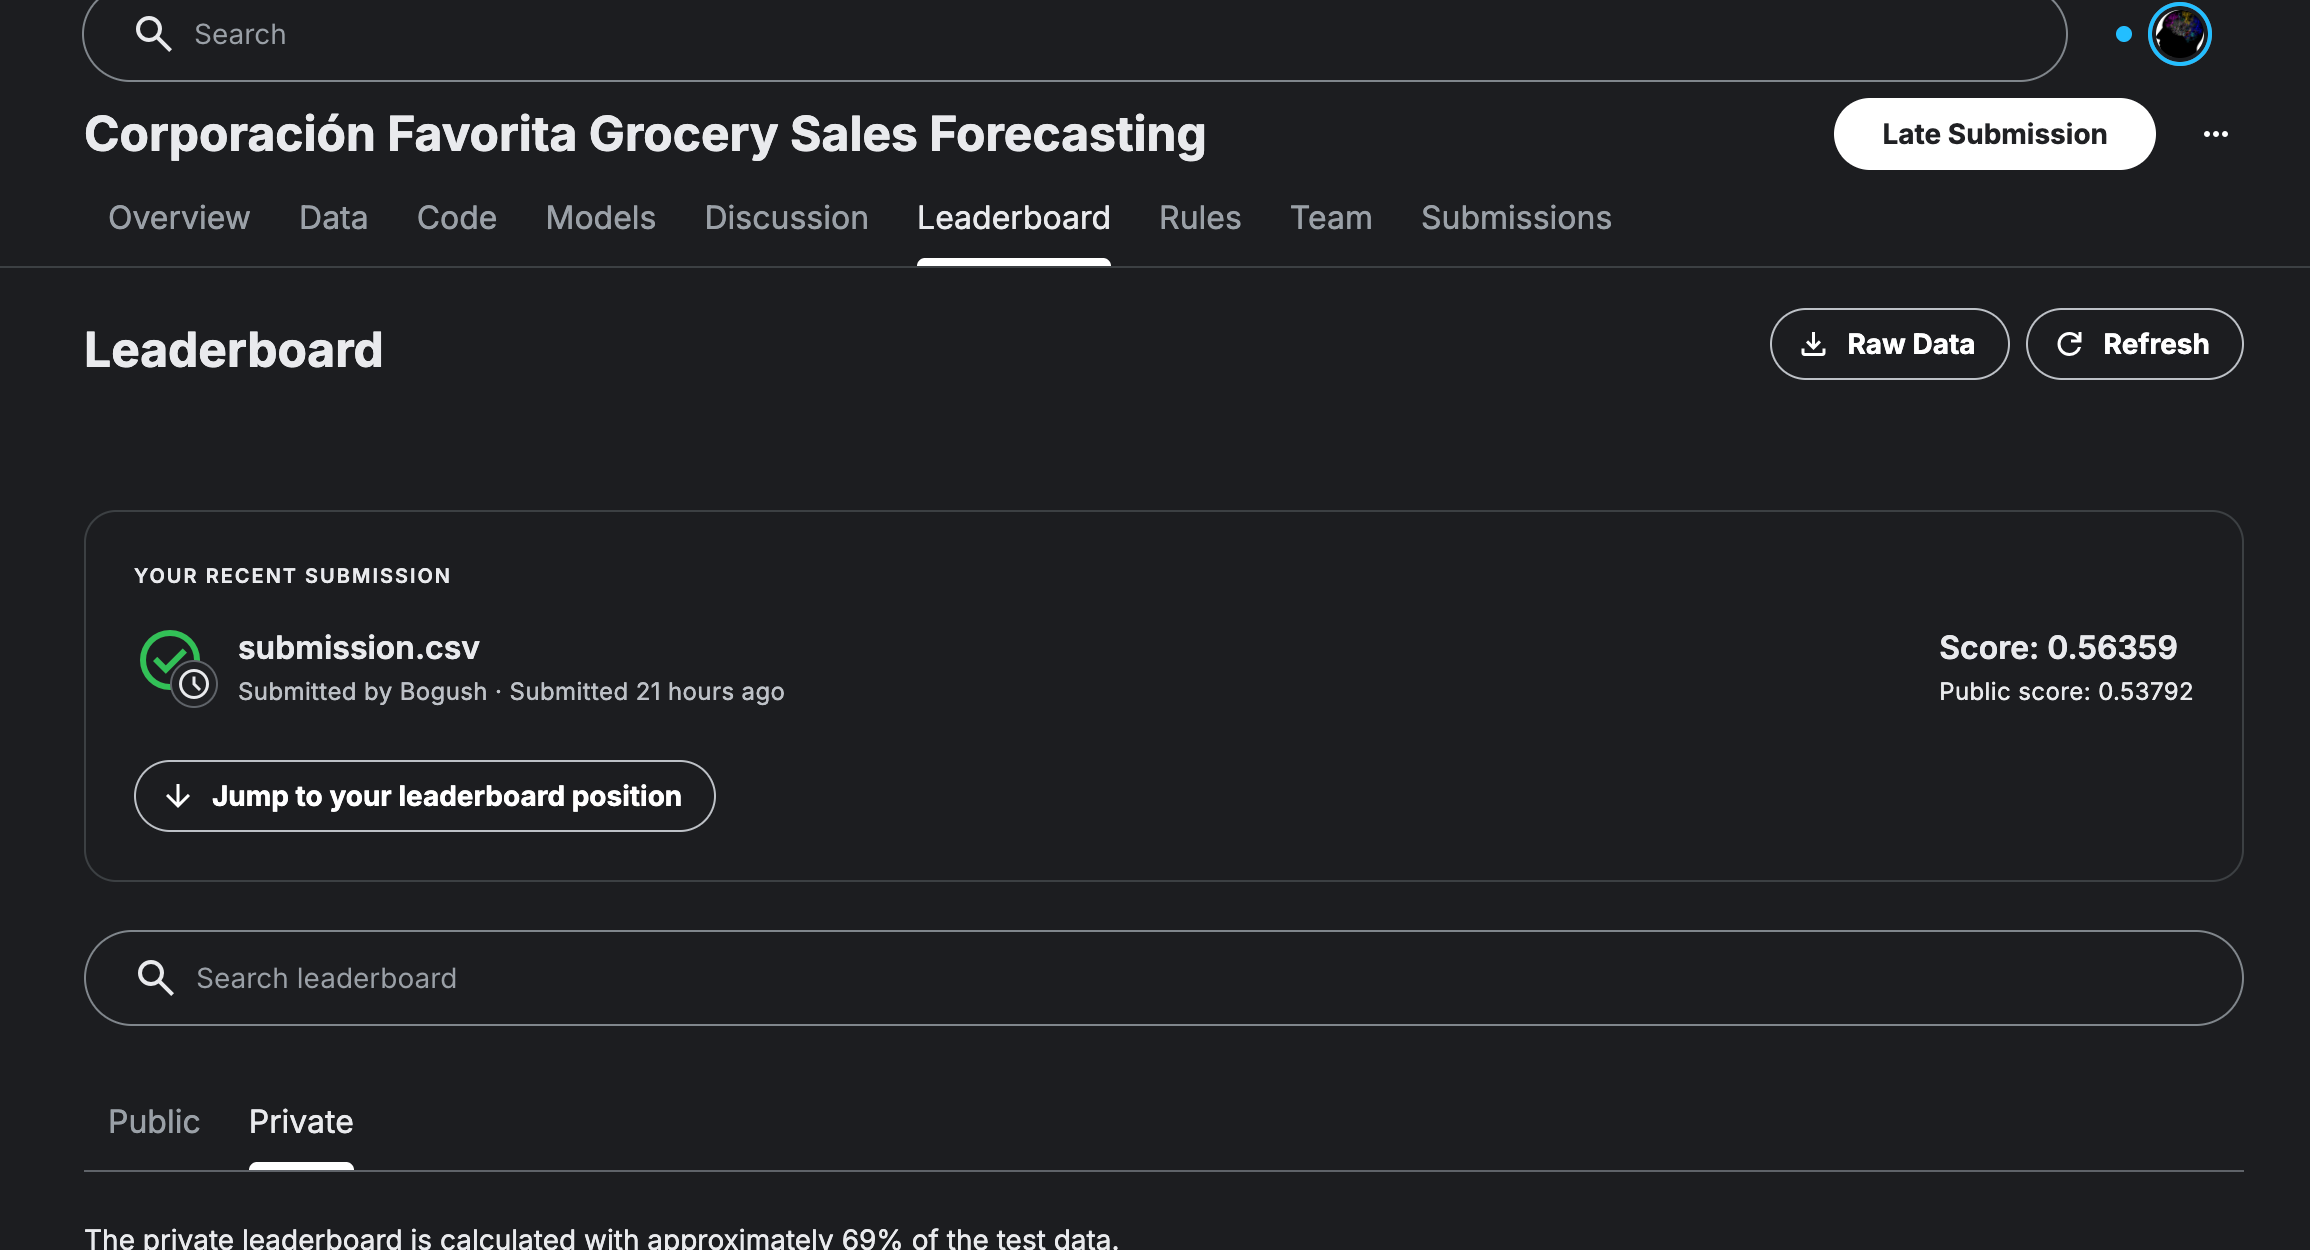

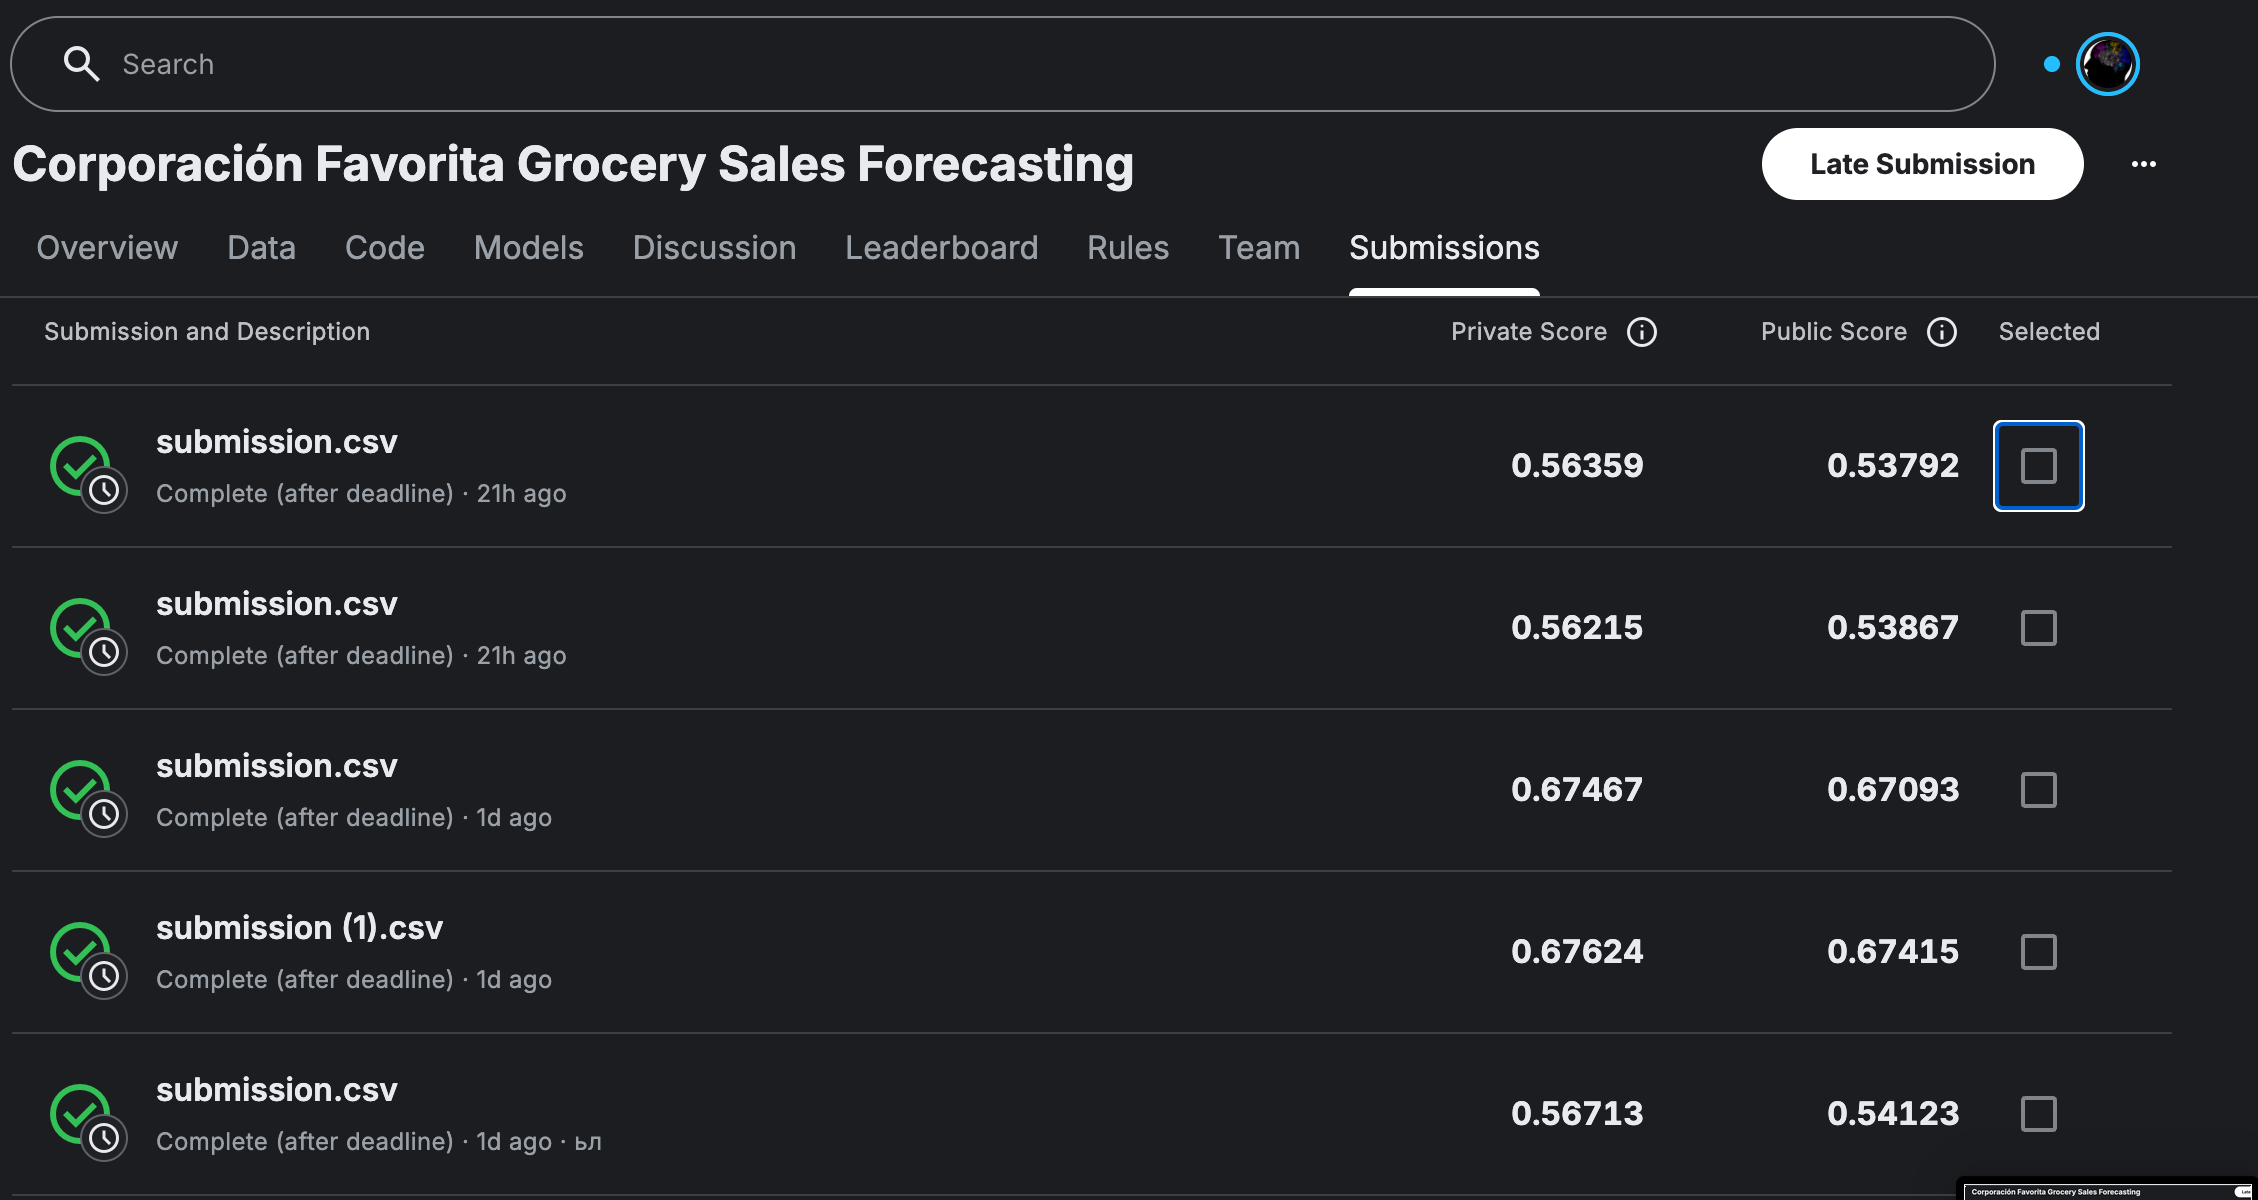